# Эксперимент 4: Непрерывные действия (дискретизация) + Softmax-SARSA
Действия a,b ∈ [0,1] дискретизованы на n+1 точек. Вознаграждение: r*a*b + p*(1-a)*b + q*a*(1-b) + s*(1-a)*(1-b).
Используем softmax-политику с параметром beta и SARSA-обновления с gamma.

In [35]:
# Настройка путей для импорта exp4
import os, sys
from pathlib import Path

# Если ноутбук открыт из папки experiments/exp4/notebooks,
# то родительская папка (..) — это experiments/exp4
exp4_path = os.path.abspath(os.path.join(os.getcwd(), '..'))

# На случай запуска из корня репозитория попробуем альтернативный путь
if not os.path.exists(os.path.join(exp4_path, 'continuous_game.py')):
    repo_root = Path(os.getcwd()).resolve()
    alt = os.path.join(str(repo_root), 'experiments', 'exp4')
    if os.path.exists(os.path.join(alt, 'continuous_game.py')):
        exp4_path = alt

if exp4_path not in sys.path:
    sys.path.insert(0, exp4_path)
print('📦 sys.path настроен для exp4:', exp4_path)

📦 sys.path настроен для exp4: /Users/macbook/Documents/learning/rl-projects/TheoryGamesDL/experiments/exp4


In [36]:
import numpy as np
import matplotlib.pyplot as plt
try:
    from tqdm import tqdm
except Exception:
    def tqdm(x):
        return x
from continuous_game import ContinuousBimatrixGame, PayoffParams
from softmax_sarsa_agent import SoftmaxSARSAAgent
from viz import plot_two_policies_heatmaps_over_time
print('✅ Импорты готовы')

✅ Импорты готовы


100%|██████████| 10000/10000 [00:00<00:00, 14416.24it/s]


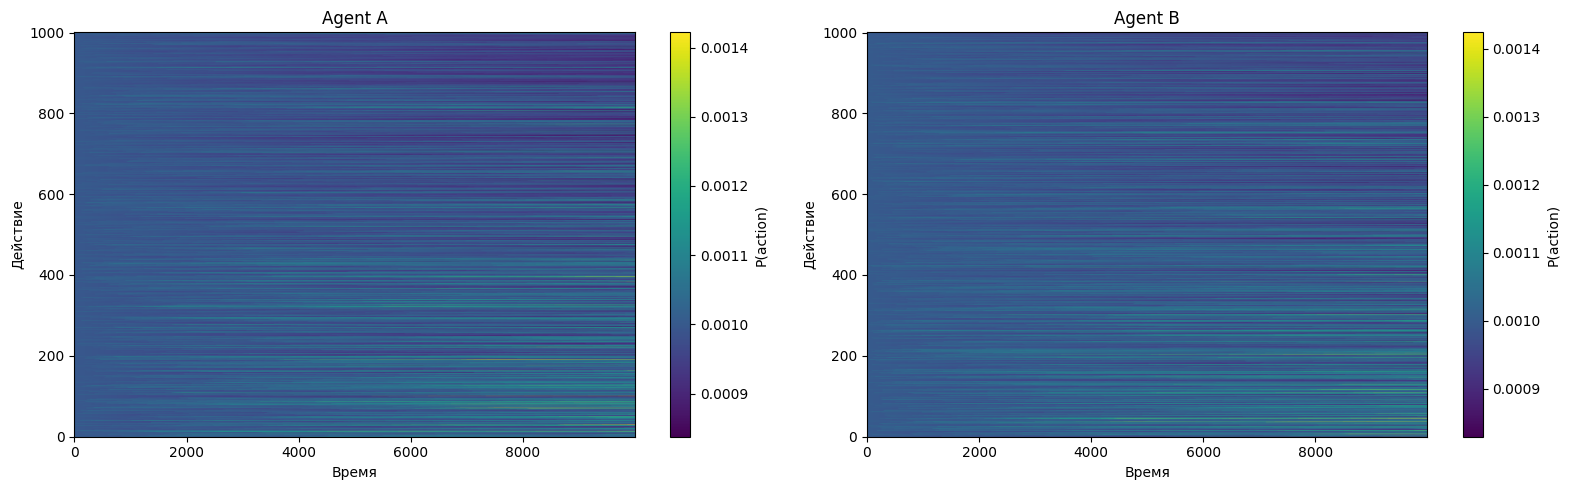

In [37]:
# Параметры PD-подобной игры
params = PayoffParams(r=3.0, p=4.0, q=0.0, s=1.0)
n = 1000
steps = 10000
alpha = 0.01
gamma = 0.7
beta = 1.0
game = ContinuousBimatrixGame(params, n=n)
agent_a = SoftmaxSARSAAgent(game.num_actions(), alpha=alpha, gamma=gamma, beta=beta, seed=0)
agent_b = SoftmaxSARSAAgent(game.num_actions(), alpha=alpha, gamma=gamma, beta=beta, seed=1)
policies_a, policies_b = [], []
a = agent_a.start_episode(); b = agent_b.start_episode()
for t in tqdm(range(steps)):
    r_a = game.payoff_player0(a, b)
    r_b = game.payoff_player1(a, b)
    next_a = agent_a.choose_action()
    next_b = agent_b.choose_action()
    agent_a.step(r_a, next_action=next_a)
    agent_b.step(r_b, next_action=next_b)
    policies_a.append(agent_a.get_action_probs())
    policies_b.append(agent_b.get_action_probs())
    a, b = next_a, next_b
plot_two_policies_heatmaps_over_time(policies_a, policies_b, title_a='Agent A', title_b='Agent B')

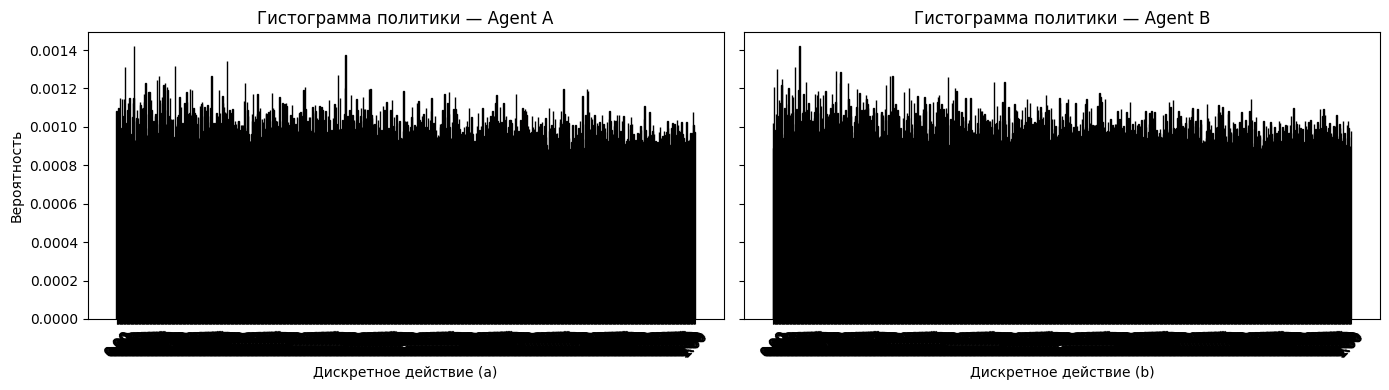

In [38]:
# Гистограмма (столбчатая диаграмма) текущей политики для обоих агентов
import numpy as np
import matplotlib.pyplot as plt

# Берём последнюю оценку политики (после обучения)
pa = np.array(policies_a[-1])
pb = np.array(policies_b[-1])
actions = game.grid()  # значения a,b из [0,1] (n+1 точек)
idx = np.arange(len(actions))

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
axes[0].bar(idx, pa, color='steelblue', edgecolor='black')
axes[0].set_title('Гистограмма политики — Agent A')
axes[0].set_xlabel('Дискретное действие (a)')
axes[0].set_ylabel('Вероятность')
axes[0].set_xticks(idx)
axes[0].set_xticklabels([f"{x:.2f}" for x in actions], rotation=45)

axes[1].bar(idx, pb, color='salmon', edgecolor='black')
axes[1].set_title('Гистограмма политики — Agent B')
axes[1].set_xlabel('Дискретное действие (b)')
axes[1].set_xticks(idx)
axes[1].set_xticklabels([f"{x:.2f}" for x in actions], rotation=45)

plt.tight_layout()
plt.show()

Argmax A: 0.03 | Argmax B: 0.046


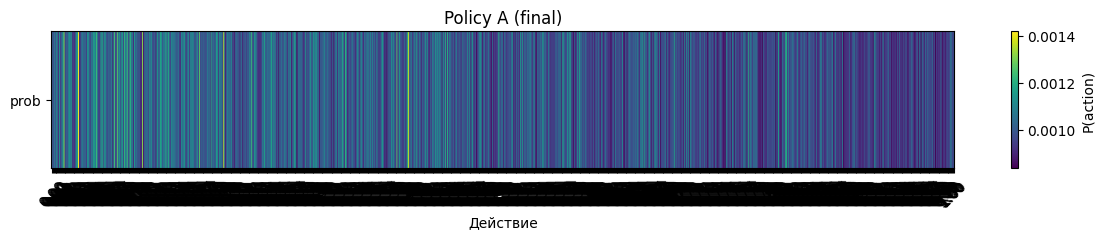

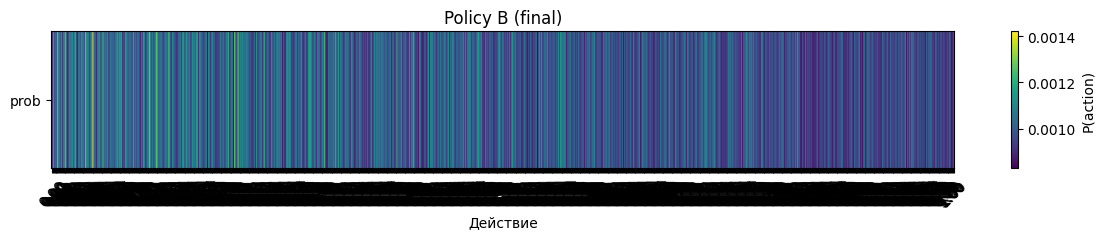

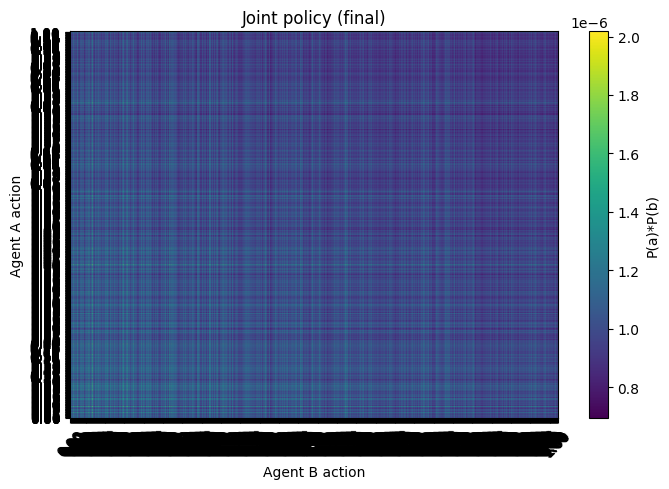

In [39]:
# Итоговые результаты: теплокарты политики (1D и совместная 2D)
import importlib
import viz  # перезагрузим модуль на случай, если он обновлялся
importlib.reload(viz)
from viz import plot_policy_heatmap, plot_joint_policy_heatmap
import numpy as np

# Берём финальные распределения из собранных списков
pa = np.array(policies_a[-1])  # Agent A
pb = np.array(policies_b[-1])  # Agent B
actions = game.grid()

# Печатаем краткое резюме (моды политик)
print("Argmax A:", actions[int(pa.argmax())], "| Argmax B:", actions[int(pb.argmax())])

# Теплокарты отдельных политик (вектор вероятностей как 1xA)
plot_policy_heatmap(pa, actions=actions, title="Policy A (final)")
plot_policy_heatmap(pb, actions=actions, title="Policy B (final)")

# Совместная теплокарта как внешнее произведение политик A и B
plot_joint_policy_heatmap(pa, pb, actions=actions, title="Joint policy (final)")